Block1: 載入package


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from tqdm import tqdm, trange
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.cluster import KMeans
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
from scipy.signal import savgol_filter

import lightgbm as lgb
from kneed import KneeLocator

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go
import plotly
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
import cufflinks as cf
cf.set_config_file(offline=True)
# Input data files are available i

import datetime

import warnings
warnings.filterwarnings('ignore')

Block2: 自定義function <br>
(1) 正規化資料 <br>
(2) 做kmeans分群標記 <br>
(3) 找kmeans最佳群數 <br>


In [8]:
def MinMaxScaler(data):
    return (data-np.min(data))/(np.max(data)-np.min(data))

def Kmeans_clustering(df, clusterNum, max_iter=1000, n_jobs=-1):
    '''
    Function for doing kmeans clustering.
    Inputs should include at least the dataframe of variables and cluster number you want.
    '''
    # Normalize the dataframe
    scaler = StandardScaler()
    scaler.fit(df) 
    df_std = pd.DataFrame(data=scaler.transform(df), columns=df.columns, index=df.index)
    
    # Kmeans clustering
    km_model = KMeans(n_clusters=clusterNum, max_iter=max_iter, random_state=666, n_init=10)
    km_model = km_model.fit(df_std)
    
    clusterdf= pd.DataFrame(data=km_model.labels_, columns=['ClusterNo'])
    clusterdf.index = df.index
    
    return clusterdf

def Kmeans_bestClusterNum(df, range_min, range_max, max_iter=1000, n_jobs=-1):
    '''
    Function for finding optimal number of kmeans clustering.
    Inputs should include at least the dataframe of variables, and search range of cluster number (min & max cluster number).
    '''    
    
    # Normalize the dataframe
    scaler = StandardScaler()
    scaler.fit(df) 
    df_std = pd.DataFrame(data=scaler.transform(df), columns=df.columns, index=df.index)       
    
    # Calculate inertia for each cluster number in the research range
    sum_of_squared_distances = [] #Inertia of all clustering results
    ks = range(range_min,range_max+1)
    for k in ks:
        kmeans_fit = KMeans(n_clusters = k, max_iter=max_iter, random_state=666, n_init=10).fit(df_std)
        cluster_labels = kmeans_fit.labels_
        sum_of_squared_distances.append(kmeans_fit.inertia_)
        
    # Use kneed package to locate the elbow / knee of the curve line
    kn = KneeLocator(list(ks), sum_of_squared_distances, S=1.0, curve='convex', direction='decreasing')  
    
    # Plot the result of finding optimal cluster number
    plt.xlabel('k')
    plt.ylabel('sum_of_squared_distances')
    plt.title('The Elbow Method showing the optimal k')
    plt.plot(ks, sum_of_squared_distances, 'bx-')
    plt.vlines(kn.knee, plt.ylim()[0], plt.ylim()[1], linestyles='dashed')
    plt.show()
    
    print('Optimal clustering number:'+str(kn.knee))
    print('----------------------------')    
    
    return kn.knee

Block3-4：讀取csv檔和修正cloud_coverage。<br>
照ASHRAE競賽的說明，cloud_coverage是用Okta規則，數值是0-9，原始資料255可能代表缺值，改成10讓數值範圍所小到0-10。


In [3]:
train_features = pd.read_csv('../input/energy-anomaly-detection/train_features.csv')
train_features['cloud_coverage'] = train_features['cloud_coverage'].replace({255:10})

In [4]:
test_features = pd.read_csv('../input/energy-anomaly-detection/test_features.csv', index_col=0)
test_features['cloud_coverage'] = test_features['cloud_coverage'].replace({255:10})

Block5-8：合併train和test data，依照building-id做kmeans分群。這部分可能因為scikit-learn版本不同沒辦法重現，有做些微調整。 

Block5: 合併train和test data，移除平均10個標準差以外的資料。

In [5]:
merged_data = pd.concat([train_features, test_features],axis=0,ignore_index=True)
merged_data_pivot = merged_data.pivot_table(index='timestamp',columns='building_id',values='meter_reading')

# remove outliers (10 std away from avg)
merged_data_pivot = (merged_data_pivot-merged_data_pivot.mean())/merged_data_pivot.std()
merged_data_pivot = merged_data_pivot[merged_data_pivot<10]
merged_data_pivot = merged_data_pivot[merged_data_pivot>-10]

merged_data_pivot = (merged_data_pivot-merged_data_pivot.mean())/merged_data_pivot.std()
merged_data_pivot = merged_data_pivot[merged_data_pivot<10]
merged_data_pivot = merged_data_pivot[merged_data_pivot>-10]

merged_data_pivot.index = pd.to_datetime(merged_data_pivot.index)

merged_data_pivot

building_id,1,18,19,26,32,38,39,41,55,69,...,1317,1318,1319,1320,1321,1322,1323,1353,1384,1425
timestamp,,,,,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.782113,-1.222397,-0.295801,-0.724083,-0.491904,-0.581884,-0.121795,-0.855589,-0.896302,-1.086031
2016-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.785629,-1.379572,-0.590580,-0.723904,-0.612916,-0.824660,-0.050955,-0.835054,-0.896302,-1.055597
2016-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.797065,-1.222410,-1.180016,-0.872948,-0.722403,-0.750251,-0.121795,-0.848744,-0.735114,-1.021960
2016-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.808502,-1.052165,-0.590580,-0.415254,-0.676303,-0.562336,-0.357927,-0.876124,-1.218678,-1.102049
2016-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.860365,-1.248604,-0.885310,-1.071047,-0.710878,-0.280418,-1.042711,-0.828209,-1.702243,-1.014752
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-31 19:00:00,-2.118043,0.296662,-1.094677,2.117905,0.668420,1.096717,-0.195342,1.026779,0.278385,0.808463,...,-1.077512,0.337358,NaN,-0.760755,4.100800,-0.246380,-0.145408,-1.259441,-2.024620,-0.896621
2016-12-31 20:00:00,-2.762260,0.194716,-0.946744,1.932770,-0.592391,1.087021,-0.170175,1.038128,0.658975,0.800188,...,-1.040601,0.304288,NaN,-0.746354,3.132702,-0.224326,-0.287087,-1.252596,-1.863431,-1.014352
2016-12-31 21:00:00,-2.717712,0.105477,-1.346097,2.148752,-1.082701,1.016505,-0.226799,1.032404,0.844583,0.816739,...,-1.394012,0.345019,NaN,-1.009660,2.700515,-0.709104,-0.074568,-1.259441,-1.702243,-0.979914


Block6: 取自然對數

In [6]:
merged_data_pivot = np.log1p(merged_data_pivot)

Block7: 找Kmeans最佳群數，原本直接設10。因為block8沒辦法重現，所以用function給的參數

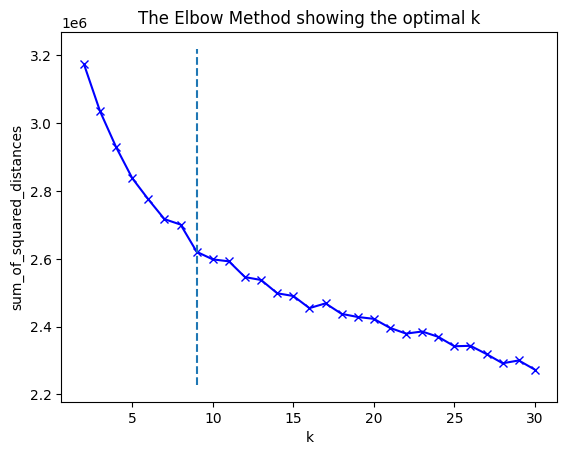

Optimal clustering number:9
----------------------------


In [9]:
df_PM_temp = merged_data_pivot.copy()
df_PM_temp = df_PM_temp.T

#bestClusterNum_dept = 10
bestClusterNum_dept = Kmeans_bestClusterNum(df=df_PM_temp.fillna(0), range_min=2, range_max=30, max_iter=10000, n_jobs=-1)

In [ ]:
bestClusterNum_dept #確認一下數字是多少

np.int64(9)

Block8: 做kmeans分群

Cluster No.: 0
Amount of meters: 3


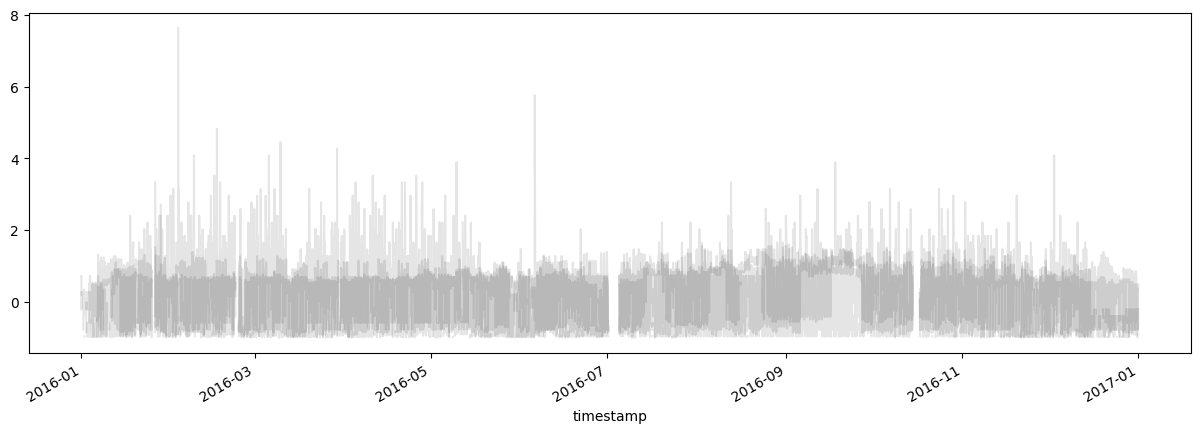

-----------------------------------------------------------------------------------
Cluster No.: 1
Amount of meters: 38


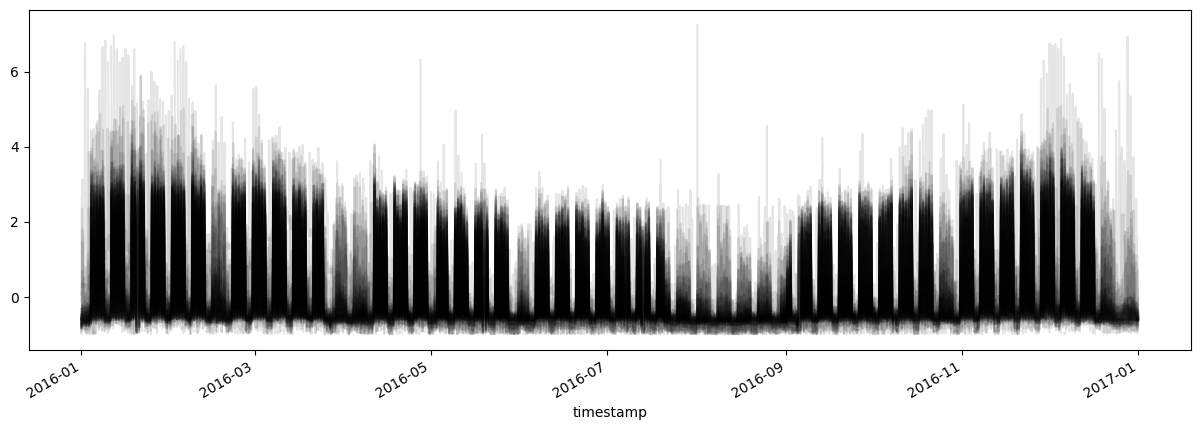

-----------------------------------------------------------------------------------
Cluster No.: 2
Amount of meters: 102


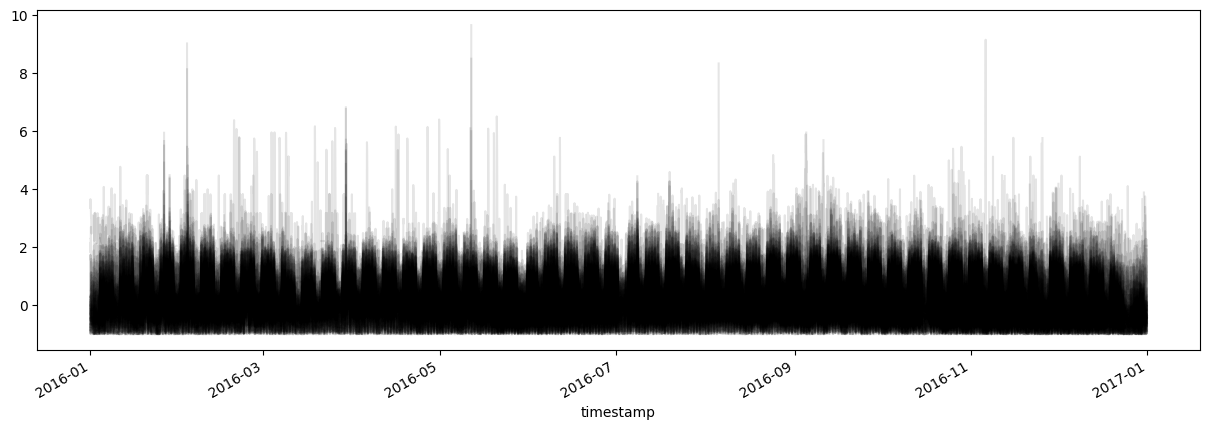

-----------------------------------------------------------------------------------
Cluster No.: 3
Amount of meters: 67


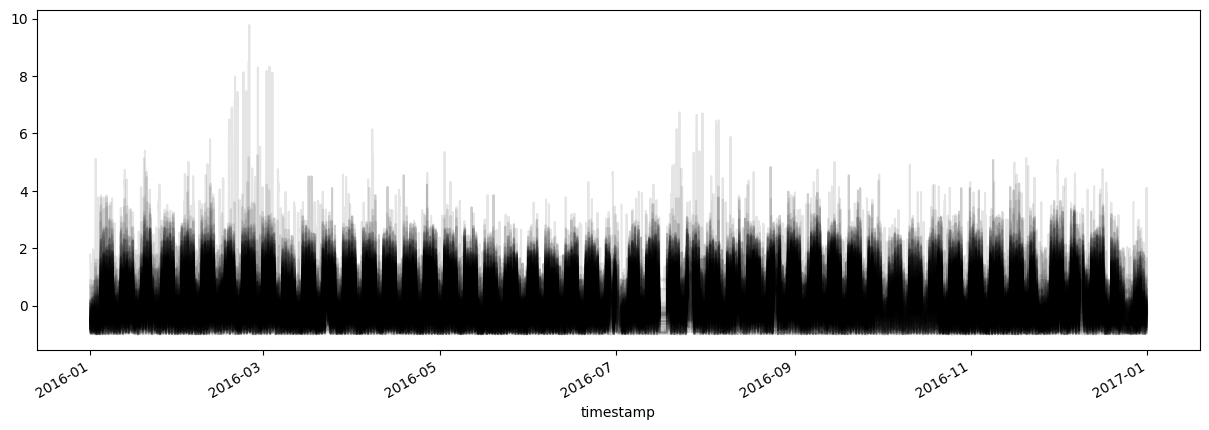

-----------------------------------------------------------------------------------
Cluster No.: 4
Amount of meters: 30


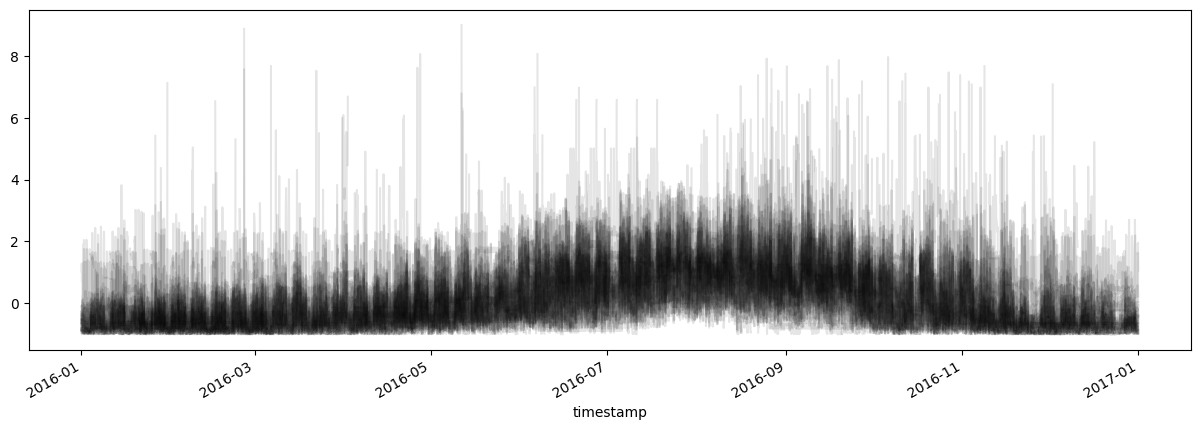

-----------------------------------------------------------------------------------
Cluster No.: 5
Amount of meters: 28


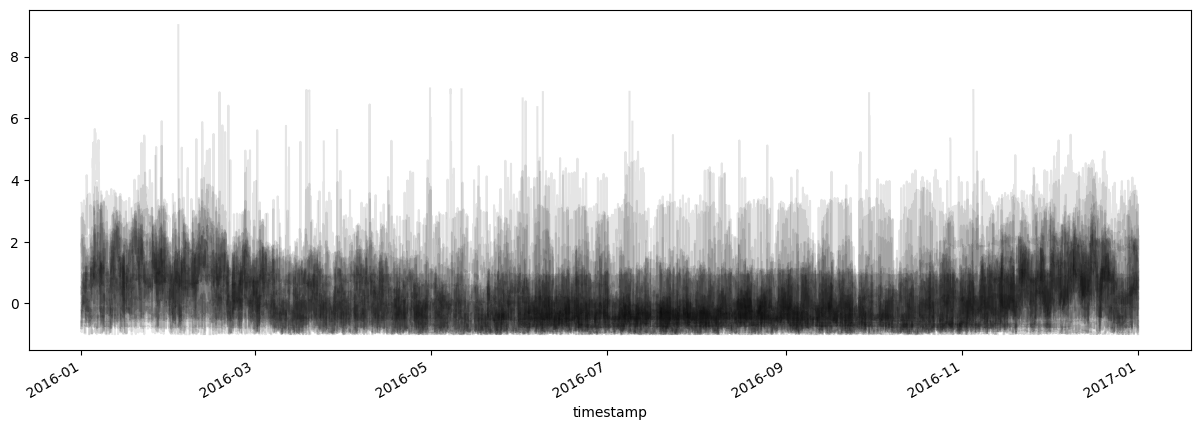

-----------------------------------------------------------------------------------
Cluster No.: 6
Amount of meters: 24


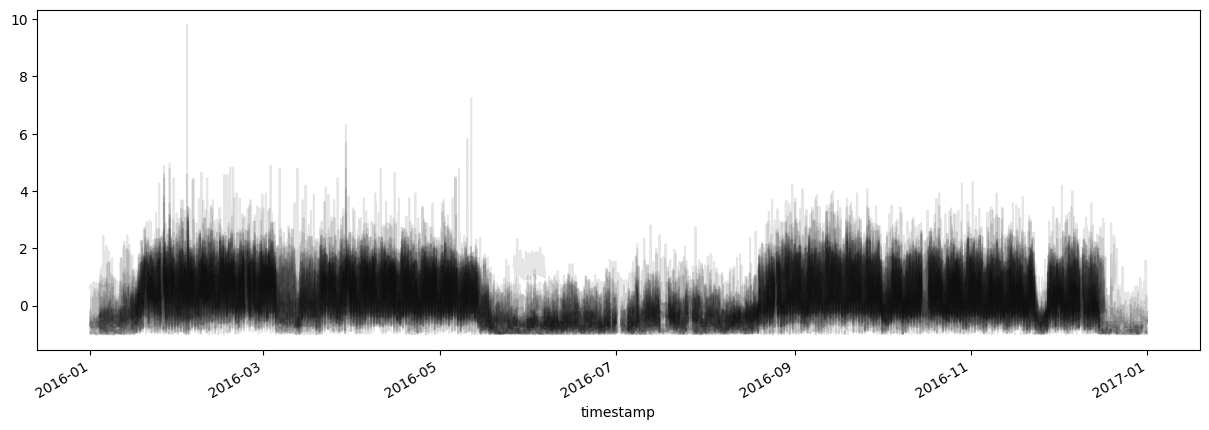

-----------------------------------------------------------------------------------
Cluster No.: 7
Amount of meters: 83


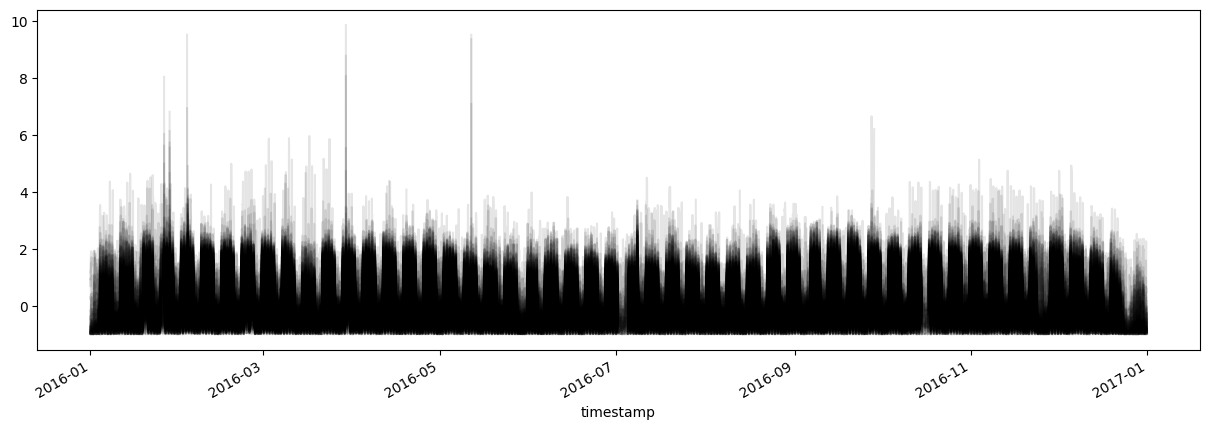

-----------------------------------------------------------------------------------
Cluster No.: 8
Amount of meters: 31


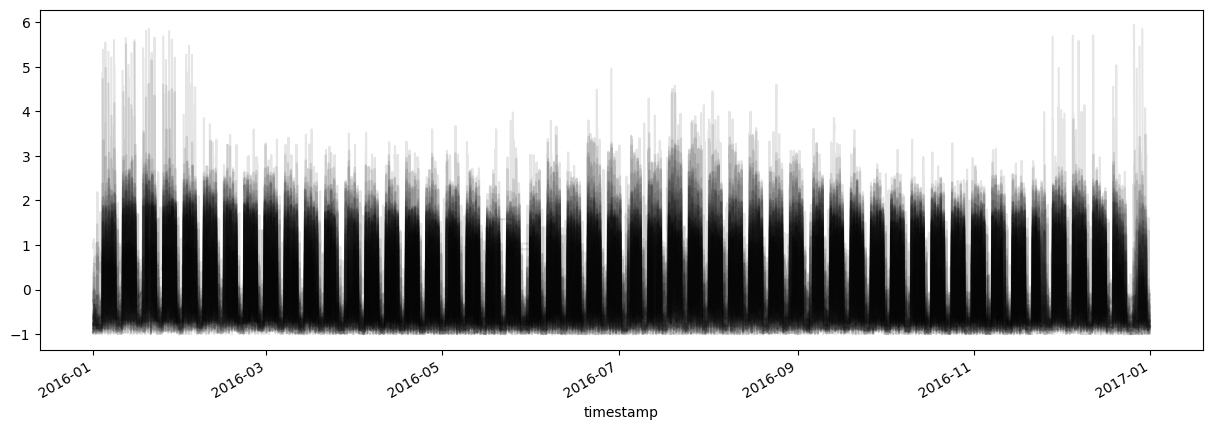

-----------------------------------------------------------------------------------


In [11]:
df_PM_temp['ClusterNo'] = Kmeans_clustering(df=df_PM_temp.fillna(0), clusterNum=bestClusterNum_dept, max_iter=10000, n_jobs=-1)

for ClusterNo in df_PM_temp['ClusterNo'].sort_values().unique():
    df_plot = df_PM_temp[df_PM_temp['ClusterNo']==ClusterNo].T.drop('ClusterNo')
    df_plot = np.expm1(df_plot)
    print('Cluster No.: ' + str(ClusterNo))    
    print('Amount of meters: ' + str(len(df_plot.T)))
    df_plot.plot(figsize=(15,5),color='black',alpha=0.1,legend=False)
    plt.show()
    print('-----------------------------------------------------------------------------------')

block9: 把kmeans結果併回訓練集

In [12]:
train_features = train_features.merge(df_PM_temp['ClusterNo'].reset_index(),on='building_id',how='left')

In [ ]:
train_features.head(20) #確認一下內容

,building_id,timestamp,meter_reading,anomaly,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,...,gte_meter_hour,gte_meter_weekday,gte_meter_month,gte_meter_building_id,gte_meter_primary_use,gte_meter_site_id,gte_meter_building_id_hour,gte_meter_building_id_weekday,gte_meter_building_id_month,ClusterNo
0,1,2016-01-01 00:00:00,NaN,0,0,Education,2720,104,0,19.4,...,3.981,4.146,4.12,3.569,4.489,4.079,3.554,3.538,3.845,2
1,32,2016-01-01 00:00:00,NaN,0,0,Office,48392,105,0,19.4,...,3.981,4.146,4.12,4.513,4.211,4.079,4.128,4.579,4.317,2
2,41,2016-01-01 00:00:00,NaN,0,0,Office,93860,68,0,19.4,...,3.981,4.146,4.12,4.108,4.211,4.079,4.103,4.140,4.114,5
3,55,2016-01-01 00:00:00,NaN,0,0,Office,16726,111,0,19.4,...,3.981,4.146,4.12,3.506,4.211,4.079,3.308,3.565,3.813,5
4,69,2016-01-01 00:00:00,NaN,0,0,Parking,387638,100,0,19.4,...,3.981,4.146,4.12,3.035,3.623,4.079,3.892,3.090,3.577,5
5,79,2016-01-01 00:00:00,NaN,0,0,Office,36240,110,0,19.4,...,3.981,4.146,4.12,5.173,4.211,4.079,5.124,5.177,4.647,2
6,82,2016-01-01 00:00:00,NaN,0,0,Office,10743,74,0,19.4,...,3.981,4.146,4.12,2.778,4.211,4.079,2.795,2.782,3.449,5
7,91,2016-01-01 00:00:00,NaN,0,0,Education,68094,103,0,19.4,...,3.981,4.146,4.12,4.801,4.489,4.079,4.324,4.808,4.461,2
8,107,2016-01-01 00:00:00,175.184,1,1,Education,97532,105,10,3.8,...,3.981,4.146,4.12,5.109,4.489,4.588,4.877,5.098,5.977,5
9,108,2016-01-01 00:00:00,NaN,0,1,Education,81580,13,5,3.8,...,3.981,4.146,4.12,5.477,4.489,4.588,5.361,5.510,5.347,2


block10: 填補缺失值。<br>
pandas有改版這邊直接跑會error，mean()要加numeric_only=True

In [14]:

"""
def impute_nulls(data):
    # 根據 building_id 分組，並對 meter_reading 欄位的空值補上該組的平均值
    data['meter_reading'] = data.groupby('building_id')['meter_reading'].transform(lambda x: x.fillna(x.mean()))
    return data

"""
def impute_nulls(data):
    mean_reading = data.groupby('building_id').mean(numeric_only=True)['meter_reading']
    
    building_id = mean_reading.index
    values = mean_reading.values
    
    for i, idx in tqdm(enumerate(building_id)):
        data[data['building_id']==idx] = data[data['building_id']==idx].fillna(values[i]) 
    
    return data

train_features = impute_nulls(train_features)

200it [01:33,  2.14it/s]


block11: 計算數值差異，時間區間：正負24小時內每1小時；正負168小時（7 天）每24小時（每天）

In [15]:
#value change features(diff)
train_feature = pd.read_csv('../input/energy-anomaly-detection/train_features.csv')
for shift_hours in tqdm(list(np.arange(-24,0))+list(np.arange(1,24+1))+list(np.arange(-24*7,-24,24))+list(np.arange(24+24,24*7+1,24))):
    shift_hours = int(shift_hours)
    meter_reading_shift = train_feature[['building_id', 'timestamp', 'meter_reading']]
    meter_reading_shift['timestamp'] = pd.to_datetime(meter_reading_shift['timestamp']) + datetime.timedelta(hours=shift_hours)
    meter_reading_shift['timestamp'] = meter_reading_shift['timestamp'].astype('str')
    meter_reading_shift = meter_reading_shift.rename(columns={'meter_reading':'lag_value_'+str(shift_hours)})
    train_feature = train_feature.merge(meter_reading_shift, on=['building_id', 'timestamp'], how='left')
    
    train_features['lag_value_'+str(shift_hours)] = train_feature['lag_value_'+str(shift_hours)]-train_feature['meter_reading']

100%|██████████| 60/60 [03:56<00:00,  3.94s/it]


block12: 計算比例差異，時間區間：正負24小時內每1小時；正負168小時（7 天）每24小時（每天）

In [16]:
#value change features(ratio)
train_feature = pd.read_csv('../input/energy-anomaly-detection/train_features.csv')
for shift_hours in tqdm(list(np.arange(-24,0))+list(np.arange(1,24+1))+list(np.arange(-24*7,-24,24))+list(np.arange(24+24,24*7+1,24))):
    shift_hours = int(shift_hours)
    meter_reading_shift = train_feature[['building_id', 'timestamp', 'meter_reading']]
    meter_reading_shift['timestamp'] = pd.to_datetime(meter_reading_shift['timestamp']) + datetime.timedelta(hours=shift_hours)
    meter_reading_shift['timestamp'] = meter_reading_shift['timestamp'].astype('str')
    meter_reading_shift = meter_reading_shift.rename(columns={'meter_reading':'lag_value_'+str(shift_hours)})
    train_feature = train_feature.merge(meter_reading_shift, on=['building_id', 'timestamp'], how='left')
    
    train_features['lag_value_ratio_'+str(shift_hours)] = (train_feature['lag_value_'+str(shift_hours)]+1)/(train_feature['meter_reading']+1)

100%|██████████| 60/60 [03:51<00:00,  3.86s/it]


block13: 用savitzky golay filter計算平滑值及和實際數值的差異。<br>
差值有些不一樣，數量級在e-14，推測是float估計值的誤差

In [17]:
df_savgol_train = []

for building_id in tqdm(train_features['building_id'].unique()):
    df_temp = train_features[train_features['building_id']==building_id]
    df_temp['meter_reading_smooth'] = savgol_filter(df_temp['meter_reading'].fillna(method='ffill'), 5, 3)
    df_temp['Residual_savgol_w5p3'] = (df_temp['meter_reading'] - df_temp['meter_reading_smooth'])
    df_savgol_train.append(df_temp)
    
df_savgol_train = pd.concat(df_savgol_train,axis=0).sort_index()
df_savgol_train

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:08<00:00, 24.17it/s]


,building_id,timestamp,meter_reading,anomaly,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,...,lag_value_ratio_-72,lag_value_ratio_-48,lag_value_ratio_48,lag_value_ratio_72,lag_value_ratio_96,lag_value_ratio_120,lag_value_ratio_144,lag_value_ratio_168,meter_reading_smooth,Residual_savgol_w5p3
0,1,2016-01-01 00:00:00,35.267879,0,0,Education,2720,104,0,19.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.267879,2.131628e-14
1,32,2016-01-01 00:00:00,98.400360,0,0,Office,48392,105,0,19.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.400360,2.842171e-14
2,41,2016-01-01 00:00:00,61.162877,0,0,Office,93860,68,0,19.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61.162877,0.000000e+00
3,55,2016-01-01 00:00:00,33.911298,0,0,Office,16726,111,0,19.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.911298,2.131628e-14
4,69,2016-01-01 00:00:00,30.782749,0,0,Parking,387638,100,0,19.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.782749,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1749489,1316,2016-12-31 23:00:00,38.844000,0,14,Entertainment/public assembly,49975,255,0,-29.9,...,NaN,NaN,1.003915,0.980373,1.084705,1.092536,1.125489,1.072934,38.933300,-8.930000e-02
1749490,1318,2016-12-31 23:00:00,202.893000,0,14,Entertainment/public assembly,73488,255,0,-29.9,...,NaN,NaN,1.049962,0.981799,0.995522,0.937624,0.917417,0.928379,203.199457,-3.064571e-01
1749491,1319,2016-12-31 23:00:00,132.040616,0,14,Entertainment/public assembly,287419,255,0,-29.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,132.040616,1.136868e-13
1749492,1323,2016-12-31 23:00:00,172.000000,0,14,Office,87200,255,0,-29.9,...,NaN,NaN,1.005780,1.011561,1.028902,0.959538,1.069364,0.953757,170.942857,1.057143e+00


block14：併入資料

In [18]:
train_features['Residual_savgol_w5p3'] = df_savgol_train['Residual_savgol_w5p3']

block15：存檔

In [19]:
train_features.to_pickle('train_features.pickle')
train_features

,building_id,timestamp,meter_reading,anomaly,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,...,lag_value_ratio_-96,lag_value_ratio_-72,lag_value_ratio_-48,lag_value_ratio_48,lag_value_ratio_72,lag_value_ratio_96,lag_value_ratio_120,lag_value_ratio_144,lag_value_ratio_168,Residual_savgol_w5p3
0,1,2016-01-01 00:00:00,35.267879,0,0,Education,2720,104,0,19.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.131628e-14
1,32,2016-01-01 00:00:00,98.400360,0,0,Office,48392,105,0,19.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.842171e-14
2,41,2016-01-01 00:00:00,61.162877,0,0,Office,93860,68,0,19.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00
3,55,2016-01-01 00:00:00,33.911298,0,0,Office,16726,111,0,19.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.131628e-14
4,69,2016-01-01 00:00:00,30.782749,0,0,Parking,387638,100,0,19.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1749489,1316,2016-12-31 23:00:00,38.844000,0,14,Entertainment/public assembly,49975,255,0,-29.9,...,NaN,NaN,NaN,1.003915,0.980373,1.084705,1.092536,1.125489,1.072934,-8.930000e-02
1749490,1318,2016-12-31 23:00:00,202.893000,0,14,Entertainment/public assembly,73488,255,0,-29.9,...,NaN,NaN,NaN,1.049962,0.981799,0.995522,0.937624,0.917417,0.928379,-3.064571e-01
1749491,1319,2016-12-31 23:00:00,132.040616,0,14,Entertainment/public assembly,287419,255,0,-29.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.136868e-13
1749492,1323,2016-12-31 23:00:00,172.000000,0,14,Office,87200,255,0,-29.9,...,NaN,NaN,NaN,1.005780,1.011561,1.028902,0.959538,1.069364,0.953757,1.057143e+00
